In [365]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

np.float64(2506.199999999999)

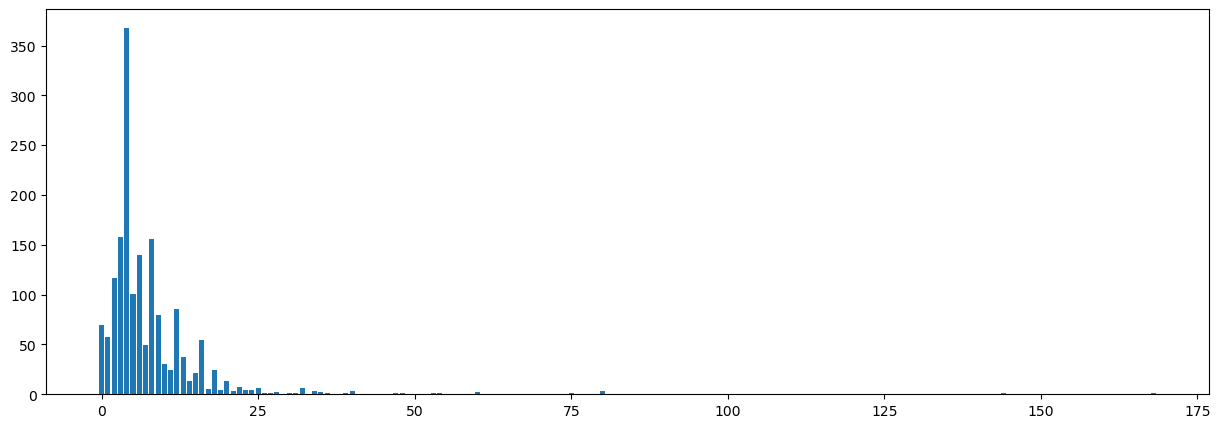

In [366]:
training_data = pd.read_csv("Train.csv")
testing_data = pd.read_csv("Test.csv")

plt.figure(figsize=(15, 5))

# training_data["Yield"] = np.log1p(training_data["Yield"])

# print(training_data["Yield"].value_counts())
# print(training_data["Yield"].value_counts().values)

plt.bar(training_data["Yield"].value_counts().index // 100, list(training_data["Yield"].value_counts().values))

training_data["Yield"].quantile(0.99)

In [367]:
for row in range(len(training_data["Yield"])):
    value = training_data["Yield"][row]
    training_data.loc[row, "Yield"] = min(value, 2500)

<BarContainer object of 354 artists>

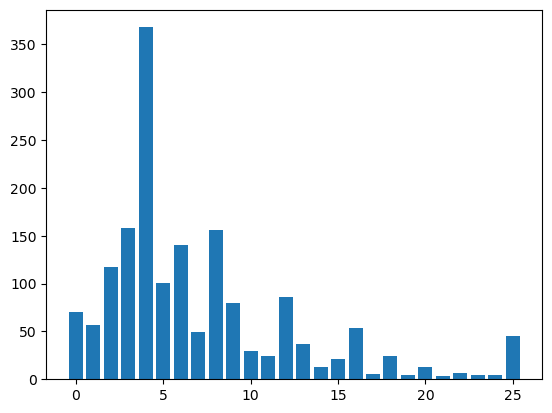

In [368]:
plt.bar(training_data["Yield"].value_counts().index // 100, list(training_data["Yield"].value_counts().values))

In [369]:
columns = training_data.columns
missing = []
for col in columns:
    if training_data[col].isna().sum() < 0.4 * len(training_data):
        continue
    missing.append(col)
for col in missing:
    print(f"{col} : {training_data[col].isna().sum()}")

Ganaura : 2417
CropOrgFYM : 2674
BasalUrea : 1704
2tdUrea : 2694
2appDaysUrea : 2700


In [370]:
for col in missing:
    training_data.drop(col, axis=1, inplace=True)

In [371]:
training_data.head()

,ID,District,Block,CultLand,CropCultLand,LandPreparationMethod,CropTillageDate,CropTillageDepth,CropEstMethod,RcNursEstDate,...,Harv_method,Harv_date,Harv_hand_rent,Threshing_date,Threshing_method,Residue_length,Residue_perc,Stubble_use,Acre,Yield
0,ID_GTFAC7PEVWQ9,Nalanda,Noorsarai,45,40,TractorPlough FourWheelTracRotavator,7/20/2022,5,Manual_PuddledRandom,6/27/2022,...,machine,11/16/2022,NaN,11/16/2022,machine,30,40,plowed_in_soil,0.312500,600
1,ID_TK40ARLSPOKS,Nalanda,Rajgir,26,26,WetTillagePuddling TractorPlough FourWheelTrac...,7/18/2022,5,Manual_PuddledRandom,6/20/2022,...,hand,11/25/2022,3.0,12/24/2022,machine,24,10,plowed_in_soil,0.312500,600
2,ID_1FJY2CRIMLZZ,Gaya,Gurua,10,10,TractorPlough FourWheelTracRotavator,6/30/2022,6,Manual_PuddledRandom,6/20/2022,...,hand,12/12/2022,480.0,1/11/2023,machine,30,10,plowed_in_soil,0.148148,225
3,ID_I3IPXS4DB7NE,Gaya,Gurua,15,15,TractorPlough FourWheelTracRotavator,6/16/2022,6,Manual_PuddledRandom,6/17/2022,...,hand,12/2/2022,240.0,12/29/2022,hand,26,10,plowed_in_soil,0.222222,468
4,ID_4T8YQWXWHB4A,Nalanda,Noorsarai,60,60,TractorPlough WetTillagePuddling,7/19/2022,4,Manual_PuddledRandom,6/21/2022,...,machine,11/30/2022,NaN,12/2/2022,machine,24,40,plowed_in_soil,0.468750,550


In [372]:
categorical_columns = []
numerical_columns = []
columns = training_data.columns
for col in columns:
    if (training_data[col].dtype == int) or (training_data[col].dtype == float):
        numerical_columns.append(col)
    else:
        categorical_columns.append(col) 

In [373]:
for col in numerical_columns:
    if sum(training_data[col].isna()) == 0:
        continue
    print(training_data[col])
    SI = SimpleImputer(strategy="mean")
    training_data[col] = SI.fit_transform(training_data[[col]])

0        2.0
1        2.0
2        2.0
3        2.0
4        2.0
        ... 
3865     NaN
3866     1.0
3867     1.0
3868     4.0
3869    10.0
Name: SeedlingsPerPit, Length: 3870, dtype: float64
0       5.0
1       5.0
2       4.0
3       NaN
4       9.0
       ... 
3865    7.0
3866    3.0
3867    6.0
3868    2.0
3869    5.0
Name: TransplantingIrrigationHours, Length: 3870, dtype: float64
0       200.0
1       125.0
2        80.0
3         NaN
4       300.0
        ...  
3865    360.0
3866      NaN
3867    120.0
3868      NaN
3869    500.0
Name: TransIrriCost, Length: 3870, dtype: float64
0       2.0
1       3.0
2       2.0
3       NaN
4       2.0
       ... 
3865    5.0
3866    3.0
3867    5.0
3868    9.0
3869    2.0
Name: StandingWater, Length: 3870, dtype: float64
0        NaN
1       15.0
2        4.0
3        6.0
4       15.0
        ... 
3865    18.0
3866     6.0
3867     NaN
3868     7.0
3869    10.0
Name: BasalDAP, Length: 3870, dtype: float64
0       15.0
1       20.0
2       

In [374]:
for col in numerical_columns:
    print(training_data[numerical_columns].isna().sum())

CultLand                        0
CropCultLand                    0
CropTillageDepth                0
SeedlingsPerPit                 0
TransplantingIrrigationHours    0
TransIrriCost                   0
StandingWater                   0
NoFertilizerAppln               0
BasalDAP                        0
1tdUrea                         0
1appDaysUrea                    0
Harv_hand_rent                  0
Residue_length                  0
Residue_perc                    0
Acre                            0
Yield                           0
dtype: int64
CultLand                        0
CropCultLand                    0
CropTillageDepth                0
SeedlingsPerPit                 0
TransplantingIrrigationHours    0
TransIrriCost                   0
StandingWater                   0
NoFertilizerAppln               0
BasalDAP                        0
1tdUrea                         0
1appDaysUrea                    0
Harv_hand_rent                  0
Residue_length                  0
R

In [375]:
for col in categorical_columns:
    if sum(training_data[col].isna()) == 0:
        continue
    print(f"{col} : {training_data[col].dtype}")
    for row in range(len(training_data)):
        print(type(training_data.loc[row, col]))
    SI = SimpleImputer(strategy="most_frequent")
    training_data[col] = SI.fit_transform(training_data[[col]]).flatten()

RcNursEstDate : object
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'float'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'float'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 

In [376]:
for col in categorical_columns:
    print(training_data[categorical_columns].isna().sum())

ID                                    0
District                              0
Block                                 0
LandPreparationMethod                 0
CropTillageDate                       0
CropEstMethod                         0
RcNursEstDate                         0
SeedingSowingTransplanting            0
NursDetFactor                         0
TransDetFactor                        0
TransplantingIrrigationSource         0
TransplantingIrrigationPowerSource    0
OrgFertilizers                        0
PCropSolidOrgFertAppMethod            0
CropbasalFerts                        0
MineralFertAppMethod                  0
FirstTopDressFert                     0
MineralFertAppMethod.1                0
Harv_method                           0
Harv_date                             0
Threshing_date                        0
Threshing_method                      0
Stubble_use                           0
dtype: int64
ID                                    0
District                   

In [377]:
dates = ["CropTillageDate", "RcNursEstDate", "SeedingSowingTransplanting", "Harv_date", "Threshing_date"]

for col in dates:
    training_data[col] = pd.to_datetime(training_data[col])
    
for col in dates:
    print(type(training_data[col][0]))

<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>


In [378]:
rows = []
for row in range(len(training_data)):
    if training_data["Harv_date"][row] > training_data["Threshing_date"][row]:
        rows.append(row)
len(rows)

0

In [379]:
for row in range(len(training_data)):
    diff = training_data["Threshing_date"][row] - training_data["Harv_date"][row]
    print(f"{diff} : {diff.days}")
    training_data.loc[row, "Thresing_date_mins_Harv_date"] = diff.days

training_data.head()

0 days 00:00:00 : 0
29 days 00:00:00 : 29
30 days 00:00:00 : 30
27 days 00:00:00 : 27
2 days 00:00:00 : 2
11 days 00:00:00 : 11
34 days 00:00:00 : 34
1 days 00:00:00 : 1
38 days 00:00:00 : 38
16 days 00:00:00 : 16
22 days 00:00:00 : 22
68 days 00:00:00 : 68
1 days 00:00:00 : 1
64 days 00:00:00 : 64
62 days 00:00:00 : 62
0 days 00:00:00 : 0
26 days 00:00:00 : 26
13 days 00:00:00 : 13
15 days 00:00:00 : 15
105 days 00:00:00 : 105
25 days 00:00:00 : 25
13 days 00:00:00 : 13
15 days 00:00:00 : 15
10 days 00:00:00 : 10
11 days 00:00:00 : 11
8 days 00:00:00 : 8
10 days 00:00:00 : 10
73 days 00:00:00 : 73
75 days 00:00:00 : 75
26 days 00:00:00 : 26
53 days 00:00:00 : 53
13 days 00:00:00 : 13
16 days 00:00:00 : 16
10 days 00:00:00 : 10
10 days 00:00:00 : 10
40 days 00:00:00 : 40
109 days 00:00:00 : 109
38 days 00:00:00 : 38
6 days 00:00:00 : 6
63 days 00:00:00 : 63
44 days 00:00:00 : 44
36 days 00:00:00 : 36
38 days 00:00:00 : 38
11 days 00:00:00 : 11
16 days 00:00:00 : 16
45 days 00:00:00 : 4

,ID,District,Block,CultLand,CropCultLand,LandPreparationMethod,CropTillageDate,CropTillageDepth,CropEstMethod,RcNursEstDate,...,Harv_date,Harv_hand_rent,Threshing_date,Threshing_method,Residue_length,Residue_perc,Stubble_use,Acre,Yield,Thresing_date_mins_Harv_date
0,ID_GTFAC7PEVWQ9,Nalanda,Noorsarai,45,40,TractorPlough FourWheelTracRotavator,2022-07-20,5,Manual_PuddledRandom,2022-06-27,...,2022-11-16,536.622443,2022-11-16,machine,30,40,plowed_in_soil,0.312500,600,0.0
1,ID_TK40ARLSPOKS,Nalanda,Rajgir,26,26,WetTillagePuddling TractorPlough FourWheelTrac...,2022-07-18,5,Manual_PuddledRandom,2022-06-20,...,2022-11-25,3.000000,2022-12-24,machine,24,10,plowed_in_soil,0.312500,600,29.0
2,ID_1FJY2CRIMLZZ,Gaya,Gurua,10,10,TractorPlough FourWheelTracRotavator,2022-06-30,6,Manual_PuddledRandom,2022-06-20,...,2022-12-12,480.000000,2023-01-11,machine,30,10,plowed_in_soil,0.148148,225,30.0
3,ID_I3IPXS4DB7NE,Gaya,Gurua,15,15,TractorPlough FourWheelTracRotavator,2022-06-16,6,Manual_PuddledRandom,2022-06-17,...,2022-12-02,240.000000,2022-12-29,hand,26,10,plowed_in_soil,0.222222,468,27.0
4,ID_4T8YQWXWHB4A,Nalanda,Noorsarai,60,60,TractorPlough WetTillagePuddling,2022-07-19,4,Manual_PuddledRandom,2022-06-21,...,2022-11-30,536.622443,2022-12-02,machine,24,40,plowed_in_soil,0.468750,550,2.0


In [380]:
rows = []
for row in range(len(training_data)):
    if training_data.iloc[row]["SeedingSowingTransplanting"] > training_data.iloc[row]["Harv_date"]:
        rows.append(row)
rows

[1822, 3133, 3404]

In [381]:
for row in rows:
    training_data.drop(row, inplace=True)
training_data = training_data.reset_index(drop=True)

In [382]:
for row in range(len(training_data)):
    diff = training_data.iloc[row]["Harv_date"] - training_data.iloc[row]["SeedingSowingTransplanting"]
    print(f"{diff} : {diff.days}")
    training_data.loc[row, "Harv_date_mins_SeedingSowingTransplanting"] = diff.days

118 days 00:00:00 : 118
128 days 00:00:00 : 128
121 days 00:00:00 : 121
138 days 00:00:00 : 138
133 days 00:00:00 : 133
110 days 00:00:00 : 110
97 days 00:00:00 : 97
136 days 00:00:00 : 136
97 days 00:00:00 : 97
105 days 00:00:00 : 105
128 days 00:00:00 : 128
113 days 00:00:00 : 113
128 days 00:00:00 : 128
124 days 00:00:00 : 124
122 days 00:00:00 : 122
158 days 00:00:00 : 158
117 days 00:00:00 : 117
96 days 00:00:00 : 96
96 days 00:00:00 : 96
134 days 00:00:00 : 134
151 days 00:00:00 : 151
95 days 00:00:00 : 95
119 days 00:00:00 : 119
97 days 00:00:00 : 97
85 days 00:00:00 : 85
82 days 00:00:00 : 82
124 days 00:00:00 : 124
89 days 00:00:00 : 89
106 days 00:00:00 : 106
113 days 00:00:00 : 113
107 days 00:00:00 : 107
88 days 00:00:00 : 88
124 days 00:00:00 : 124
68 days 00:00:00 : 68
66 days 00:00:00 : 66
97 days 00:00:00 : 97
123 days 00:00:00 : 123
110 days 00:00:00 : 110
67 days 00:00:00 : 67
84 days 00:00:00 : 84
105 days 00:00:00 : 105
117 days 00:00:00 : 117
130 days 00:00:00 : 13

In [383]:
training_data.head()
# means_district = {}
# for (idx, group) in training_data.groupby("District"):
#     mask = group.index # indeksite
#     training_data.loc[mask, "Yield_District"] = group["Yield"].mean()
#     means_district[idx] = group["Yield"].mean()

,ID,District,Block,CultLand,CropCultLand,LandPreparationMethod,CropTillageDate,CropTillageDepth,CropEstMethod,RcNursEstDate,...,Harv_hand_rent,Threshing_date,Threshing_method,Residue_length,Residue_perc,Stubble_use,Acre,Yield,Thresing_date_mins_Harv_date,Harv_date_mins_SeedingSowingTransplanting
0,ID_GTFAC7PEVWQ9,Nalanda,Noorsarai,45,40,TractorPlough FourWheelTracRotavator,2022-07-20,5,Manual_PuddledRandom,2022-06-27,...,536.622443,2022-11-16,machine,30,40,plowed_in_soil,0.312500,600,0.0,118.0
1,ID_TK40ARLSPOKS,Nalanda,Rajgir,26,26,WetTillagePuddling TractorPlough FourWheelTrac...,2022-07-18,5,Manual_PuddledRandom,2022-06-20,...,3.000000,2022-12-24,machine,24,10,plowed_in_soil,0.312500,600,29.0,128.0
2,ID_1FJY2CRIMLZZ,Gaya,Gurua,10,10,TractorPlough FourWheelTracRotavator,2022-06-30,6,Manual_PuddledRandom,2022-06-20,...,480.000000,2023-01-11,machine,30,10,plowed_in_soil,0.148148,225,30.0,121.0
3,ID_I3IPXS4DB7NE,Gaya,Gurua,15,15,TractorPlough FourWheelTracRotavator,2022-06-16,6,Manual_PuddledRandom,2022-06-17,...,240.000000,2022-12-29,hand,26,10,plowed_in_soil,0.222222,468,27.0,138.0
4,ID_4T8YQWXWHB4A,Nalanda,Noorsarai,60,60,TractorPlough WetTillagePuddling,2022-07-19,4,Manual_PuddledRandom,2022-06-21,...,536.622443,2022-12-02,machine,24,40,plowed_in_soil,0.468750,550,2.0,133.0


In [384]:
strings = []
columns = training_data.columns
for col in columns:
    print(training_data[col].dtype)
    if training_data[col].dtype == object:
        strings.append(col)
strings.pop(0)
strings

object
object
object
int64
int64
object
datetime64[ns]
int64
object
datetime64[ns]
datetime64[ns]
float64
object
object
float64
object
object
float64
float64
object
object
int64
object
float64
object
object
float64
float64
object
object
datetime64[ns]
float64
datetime64[ns]
object
int64
int64
object
float64
int64
float64
float64


['District',
 'Block',
 'LandPreparationMethod',
 'CropEstMethod',
 'NursDetFactor',
 'TransDetFactor',
 'TransplantingIrrigationSource',
 'TransplantingIrrigationPowerSource',
 'OrgFertilizers',
 'PCropSolidOrgFertAppMethod',
 'CropbasalFerts',
 'MineralFertAppMethod',
 'FirstTopDressFert',
 'MineralFertAppMethod.1',
 'Harv_method',
 'Threshing_method',
 'Stubble_use']

In [385]:
for col in strings:
    print(f"{col} : {training_data[col].nunique()}")

District : 4
Block : 9
LandPreparationMethod : 43
CropEstMethod : 4
NursDetFactor : 125
TransDetFactor : 155
TransplantingIrrigationSource : 6
TransplantingIrrigationPowerSource : 3
OrgFertilizers : 31
PCropSolidOrgFertAppMethod : 4
CropbasalFerts : 34
MineralFertAppMethod : 3
FirstTopDressFert : 14
MineralFertAppMethod.1 : 3
Harv_method : 2
Threshing_method : 2
Stubble_use : 2


In [386]:
factors = []

for col in strings:
    if training_data[col].nunique() > 10:
        factors.append(col)

factors

['LandPreparationMethod',
 'NursDetFactor',
 'TransDetFactor',
 'OrgFertilizers',
 'CropbasalFerts',
 'FirstTopDressFert']

In [387]:
def factorize(column):
    all = ""
    for row in column:
        all += row + " "
    all = set(all.split(" "))
    all.remove("")
    return all

In [388]:
for category in strings:
    print(f"{category} : {factorize(training_data[category])}")

District : {'Nalanda', 'Vaishali', 'Gaya', 'Jamui'}
Block : {'Mahua', 'Khaira', 'Wazirganj', 'Gurua', 'Garoul', 'Chehrakala', 'Rajgir', 'Jamui', 'Noorsarai'}
LandPreparationMethod : {'FourWheelTracRotavator', 'WetTillagePuddling', 'TractorPlough', 'BullockPlough', 'Other'}
CropEstMethod : {'Manual_PuddledRandom', 'LineSowingAfterTillage', 'Manual_PuddledLine', 'Broadcasting'}
NursDetFactor : {'IrrigWaterAvailability', 'CalendarDate', 'SeedAvailability', 'PreMonsoonShowers', 'LabourAvailability'}
TransDetFactor : {'IrrigWaterAvailability', 'CalendarDate', 'SeedlingAge', 'RainArrival', 'LaborAvailability'}
TransplantingIrrigationSource : {'Rainfed', 'Canal', 'Pond', 'Boring', 'TubeWell', 'Well'}
TransplantingIrrigationPowerSource : {'Solar', 'Electric', 'Diesel'}
OrgFertilizers : {'PoultryManure', 'Jeevamrit', 'Ghanajeevamrit', 'Pranamrit', 'VermiCompost', 'FYM', 'Ganaura'}
PCropSolidOrgFertAppMethod : {'RootApplication', 'Broadcasting', 'Spray', 'SoilApplied'}
CropbasalFerts : {'DAP', '

In [389]:
for category in strings:
    factors = factorize(training_data[category])
    for row in range(len(training_data)):
        for factor in factors:
            training_data.loc[row, f"{category}_{factor}"] = (factor in training_data.iloc[row][category])
training_data

,ID,District,Block,CultLand,CropCultLand,LandPreparationMethod,CropTillageDate,CropTillageDepth,CropEstMethod,RcNursEstDate,...,FirstTopDressFert_SSP,MineralFertAppMethod.1_SoilApplied,MineralFertAppMethod.1_RootApplication,MineralFertAppMethod.1_Broadcasting,Harv_method_machine,Harv_method_hand,Threshing_method_machine,Threshing_method_hand,Stubble_use_plowed_in_soil,Stubble_use_burned
0,ID_GTFAC7PEVWQ9,Nalanda,Noorsarai,45,40,TractorPlough FourWheelTracRotavator,2022-07-20,5,Manual_PuddledRandom,2022-06-27,...,False,False,False,True,True,False,True,False,True,False
1,ID_TK40ARLSPOKS,Nalanda,Rajgir,26,26,WetTillagePuddling TractorPlough FourWheelTrac...,2022-07-18,5,Manual_PuddledRandom,2022-06-20,...,False,False,False,True,False,True,True,False,True,False
2,ID_1FJY2CRIMLZZ,Gaya,Gurua,10,10,TractorPlough FourWheelTracRotavator,2022-06-30,6,Manual_PuddledRandom,2022-06-20,...,False,False,True,False,False,True,True,False,True,False
3,ID_I3IPXS4DB7NE,Gaya,Gurua,15,15,TractorPlough FourWheelTracRotavator,2022-06-16,6,Manual_PuddledRandom,2022-06-17,...,False,False,False,True,False,True,False,True,True,False
4,ID_4T8YQWXWHB4A,Nalanda,Noorsarai,60,60,TractorPlough WetTillagePuddling,2022-07-19,4,Manual_PuddledRandom,2022-06-21,...,False,False,False,True,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3862,ID_7ZZQ6R4XB4FK,Nalanda,Rajgir,28,28,WetTillagePuddling TractorPlough FourWheelTrac...,2022-07-02,6,LineSowingAfterTillage,2022-06-29,...,False,False,False,True,True,False,True,False,True,False
3863,ID_PVVDF6LK6FO8,Vaishali,Mahua,5,5,WetTillagePuddling TractorPlough FourWheelTrac...,2022-07-06,5,Manual_PuddledRandom,2022-07-08,...,False,False,False,True,False,True,False,True,True,False
3864,ID_RBYVUPRATVMW,Nalanda,Noorsarai,50,45,TractorPlough,2022-07-07,5,Manual_PuddledRandom,2022-06-15,...,False,False,False,True,False,True,False,True,True,False
3865,ID_ARE9QWENJNJ2,Jamui,Khaira,20,20,TractorPlough,2022-07-12,3,Manual_PuddledRandom,2022-06-28,...,False,False,False,True,False,True,False,True,True,False


In [390]:
for col in strings:
    training_data.drop(col, axis=1, inplace=True)
training_data

,ID,CultLand,CropCultLand,CropTillageDate,CropTillageDepth,RcNursEstDate,SeedingSowingTransplanting,SeedlingsPerPit,TransplantingIrrigationHours,TransIrriCost,...,FirstTopDressFert_SSP,MineralFertAppMethod.1_SoilApplied,MineralFertAppMethod.1_RootApplication,MineralFertAppMethod.1_Broadcasting,Harv_method_machine,Harv_method_hand,Threshing_method_machine,Threshing_method_hand,Stubble_use_plowed_in_soil,Stubble_use_burned
0,ID_GTFAC7PEVWQ9,45,40,2022-07-20,5,2022-06-27,2022-07-21,2.000000,5.000000,200.000000,...,False,False,False,True,True,False,True,False,True,False
1,ID_TK40ARLSPOKS,26,26,2022-07-18,5,2022-06-20,2022-07-20,2.000000,5.000000,125.000000,...,False,False,False,True,False,True,True,False,True,False
2,ID_1FJY2CRIMLZZ,10,10,2022-06-30,6,2022-06-20,2022-08-13,2.000000,4.000000,80.000000,...,False,False,True,False,False,True,True,False,True,False
3,ID_I3IPXS4DB7NE,15,15,2022-06-16,6,2022-06-17,2022-07-17,2.000000,8.017677,379.726908,...,False,False,False,True,False,True,False,True,True,False
4,ID_4T8YQWXWHB4A,60,60,2022-07-19,4,2022-06-21,2022-07-20,2.000000,9.000000,300.000000,...,False,False,False,True,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3862,ID_7ZZQ6R4XB4FK,28,28,2022-07-02,6,2022-06-29,2022-07-16,2.706507,7.000000,360.000000,...,False,False,False,True,True,False,True,False,True,False
3863,ID_PVVDF6LK6FO8,5,5,2022-07-06,5,2022-07-08,2022-07-30,1.000000,3.000000,379.726908,...,False,False,False,True,False,True,False,True,True,False
3864,ID_RBYVUPRATVMW,50,45,2022-07-07,5,2022-06-15,2022-07-08,1.000000,6.000000,120.000000,...,False,False,False,True,False,True,False,True,True,False
3865,ID_ARE9QWENJNJ2,20,20,2022-07-12,3,2022-06-28,2022-07-24,4.000000,2.000000,379.726908,...,False,False,False,True,False,True,False,True,True,False


In [391]:
for col in dates:
    training_data[col] = training_data[col].astype(int)
training_data.head()
training_data.to_csv("processed_data.csv", index=False)

In [392]:
X = training_data.drop(["ID", "Yield"], axis=1)
y = training_data["Yield"]

columns = X.columns

for col in columns:
    if X[col].dtype == object:
        X[col] = X[col].astype(int)
    print(f"{col} : {X[col].dtype} - {X[col][0]}")


CultLand : int64 - 45
CropCultLand : int64 - 40
CropTillageDate : int64 - 1658275200000000000
CropTillageDepth : int64 - 5
RcNursEstDate : int64 - 1656288000000000000
SeedingSowingTransplanting : int64 - 1658361600000000000
SeedlingsPerPit : float64 - 2.0
TransplantingIrrigationHours : float64 - 5.0
TransIrriCost : float64 - 200.0
StandingWater : float64 - 2.0
NoFertilizerAppln : int64 - 2
BasalDAP : float64 - 11.452359483017734
1tdUrea : float64 - 15.0
1appDaysUrea : float64 - 18.0
Harv_date : int64 - 1668556800000000000
Harv_hand_rent : float64 - 536.6224433388612
Threshing_date : int64 - 1668556800000000000
Residue_length : int64 - 30
Residue_perc : int64 - 40
Acre : float64 - 0.3125
Thresing_date_mins_Harv_date : float64 - 0.0
Harv_date_mins_SeedingSowingTransplanting : float64 - 118.0
District_Nalanda : int64 - 1
District_Vaishali : int64 - 0
District_Gaya : int64 - 0
District_Jamui : int64 - 0
Block_Mahua : int64 - 0
Block_Khaira : int64 - 0
Block_Wazirganj : int64 - 0
Block_Guru

In [393]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

In [394]:
xgb_model = XGBRegressor()

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [395]:
predictions = xgb_model.predict(X_val)

np.sqrt(mean_squared_error(predictions, y_val))

np.float64(162.57838253823908)

In [396]:
testing_data = pd.read_csv("Test.csv")
for col in missing:
    testing_data.drop(col, axis=1, inplace=True)
testing_data

,ID,District,Block,CultLand,CropCultLand,LandPreparationMethod,CropTillageDate,CropTillageDepth,CropEstMethod,RcNursEstDate,...,MineralFertAppMethod.1,Harv_method,Harv_date,Harv_hand_rent,Threshing_date,Threshing_method,Residue_length,Residue_perc,Stubble_use,Acre
0,ID_F9XXEXN2ADR2,Jamui,Khaira,20,13,TractorPlough,7/24/2022,4,Manual_PuddledLine,7/3/2022,...,Broadcasting,hand,12/2/2022,500.0,12/28/2022,hand,22,10,plowed_in_soil,0.272727
1,ID_SO3VW2X4QO93,Jamui,Khaira,25,25,TractorPlough,7/24/2022,5,Manual_PuddledRandom,7/8/2022,...,Broadcasting,hand,11/12/2022,150.0,12/20/2022,machine,28,10,plowed_in_soil,0.227273
2,ID_UKUQ7JM8E894,Nalanda,Rajgir,30,30,WetTillagePuddling TractorPlough FourWheelTrac...,7/7/2022,5,Manual_PuddledRandom,6/24/2022,...,Broadcasting,hand,11/24/2022,1200.0,12/5/2022,machine,28,10,plowed_in_soil,0.281250
3,ID_QUISMWEZR2H4,Vaishali,Mahua,15,10,WetTillagePuddling TractorPlough BullockPlough...,7/4/2022,5,Manual_PuddledRandom,6/20/2022,...,SoilApplied,hand,10/15/2022,300.0,10/25/2022,hand,30,10,plowed_in_soil,0.136364
4,ID_25JGI455VKCZ,Nalanda,Rajgir,30,10,WetTillagePuddling TractorPlough FourWheelTrac...,7/21/2022,3,Manual_PuddledRandom,6/24/2022,...,Broadcasting,machine,11/20/2022,NaN,11/20/2022,machine,26,40,plowed_in_soil,0.312500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1285,ID_6MMECMX3B728,Jamui,Khaira,20,16,TractorPlough,7/23/2022,4,Manual_PuddledLine,7/5/2022,...,Broadcasting,hand,12/1/2022,1200.0,12/23/2022,hand,23,10,plowed_in_soil,0.500000
1286,ID_GZ9YGWCLLMKN,Vaishali,Mahua,25,14,WetTillagePuddling TractorPlough FourWheelTrac...,7/7/2022,5,Manual_PuddledRandom,7/9/2022,...,NaN,hand,10/15/2022,450.0,10/20/2022,hand,28,10,plowed_in_soil,0.181818
1287,ID_01YVA2LJVYBR,Vaishali,Garoul,10,3,TractorPlough,7/6/2022,6,Manual_PuddledLine,6/18/2022,...,Broadcasting,hand,10/28/2022,600.0,11/12/2022,hand,29,10,plowed_in_soil,0.136364
1288,ID_YQRL2IOUU4SZ,Jamui,Jamui,10,10,TractorPlough BullockPlough,7/22/2022,4,Manual_PuddledRandom,6/18/2022,...,Broadcasting,hand,11/25/2022,90.0,1/28/2023,hand,29,10,plowed_in_soil,0.227273


In [397]:
categorical_columns = []
numerical_columns = []
columns = testing_data.columns
for col in columns:
    if (testing_data[col].dtype == int) or (testing_data[col].dtype == float):
        numerical_columns.append(col)
    else:
        categorical_columns.append(col) 

In [398]:
for col in numerical_columns:
    if sum(testing_data[col].isna()) == 0:
        continue
    print(testing_data[col])
    SI = SimpleImputer(strategy="mean")
    testing_data[col] = SI.fit_transform(testing_data[[col]])

0       1.0
1       4.0
2       2.0
3       2.0
4       1.0
       ... 
1285    1.0
1286    2.0
1287    1.0
1288    4.0
1289    1.0
Name: SeedlingsPerPit, Length: 1290, dtype: float64
0       2.0
1       2.0
2       4.0
3       2.0
4       6.0
       ... 
1285    3.0
1286    2.0
1287    2.0
1288    2.0
1289    2.0
Name: TransplantingIrrigationHours, Length: 1290, dtype: float64
0       200.0
1         NaN
2         NaN
3         NaN
4       400.0
        ...  
1285    200.0
1286    300.0
1287    200.0
1288    500.0
1289    100.0
Name: TransIrriCost, Length: 1290, dtype: float64
0        2.0
1        3.0
2       10.0
3        NaN
4        NaN
        ... 
1285     2.0
1286     2.0
1287     2.0
1288     3.0
1289     4.0
Name: StandingWater, Length: 1290, dtype: float64
0        6.0
1        5.0
2        9.0
3       15.0
4       20.0
        ... 
1285    12.0
1286    20.0
1287     6.0
1288     NaN
1289     5.0
Name: BasalDAP, Length: 1290, dtype: float64
0        8.0
1        7.0
2       

In [399]:
for col in numerical_columns:
    print(training_data[numerical_columns].isna().sum())

CultLand                        0
CropCultLand                    0
CropTillageDepth                0
SeedlingsPerPit                 0
TransplantingIrrigationHours    0
TransIrriCost                   0
StandingWater                   0
NoFertilizerAppln               0
BasalDAP                        0
1tdUrea                         0
1appDaysUrea                    0
Harv_hand_rent                  0
Residue_length                  0
Residue_perc                    0
Acre                            0
dtype: int64
CultLand                        0
CropCultLand                    0
CropTillageDepth                0
SeedlingsPerPit                 0
TransplantingIrrigationHours    0
TransIrriCost                   0
StandingWater                   0
NoFertilizerAppln               0
BasalDAP                        0
1tdUrea                         0
1appDaysUrea                    0
Harv_hand_rent                  0
Residue_length                  0
Residue_perc                    0
A

In [400]:
for col in categorical_columns:
    if sum(testing_data[col].isna()) == 0:
        continue
    print(f"{col} : {testing_data[col].dtype}")
    for row in range(len(testing_data)):
        print(type(testing_data.loc[row, col]))
    SI = SimpleImputer(strategy="most_frequent")
    testing_data[col] = SI.fit_transform(testing_data[[col]]).flatten()

RcNursEstDate : object
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'float'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 's

In [401]:
for col in categorical_columns:
    print(testing_data[categorical_columns].isna().sum())

ID                                    0
District                              0
Block                                 0
LandPreparationMethod                 0
CropTillageDate                       0
CropEstMethod                         0
RcNursEstDate                         0
SeedingSowingTransplanting            0
NursDetFactor                         0
TransDetFactor                        0
TransplantingIrrigationSource         0
TransplantingIrrigationPowerSource    0
OrgFertilizers                        0
PCropSolidOrgFertAppMethod            0
CropbasalFerts                        0
MineralFertAppMethod                  0
FirstTopDressFert                     0
MineralFertAppMethod.1                0
Harv_method                           0
Harv_date                             0
Threshing_date                        0
Threshing_method                      0
Stubble_use                           0
dtype: int64
ID                                    0
District                   

In [402]:
dates = ["CropTillageDate", "RcNursEstDate", "SeedingSowingTransplanting", "Harv_date", "Threshing_date"]

for col in dates:
    testing_data[col] = pd.to_datetime(testing_data[col])
    
for col in dates:
    print(type(testing_data[col][0]))

<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>


In [403]:
for row in range(len(testing_data)):
    diff = testing_data["Threshing_date"][row] - testing_data["Harv_date"][row]
    print(f"{diff} : {diff.days}")
    testing_data.loc[row, "Thresing_date_mins_Harv_date"] = diff.days

testing_data.head()

26 days 00:00:00 : 26
38 days 00:00:00 : 38
11 days 00:00:00 : 11
10 days 00:00:00 : 10
0 days 00:00:00 : 0
31 days 00:00:00 : 31
27 days 00:00:00 : 27
15 days 00:00:00 : 15
10 days 00:00:00 : 10
11 days 00:00:00 : 11
65 days 00:00:00 : 65
36 days 00:00:00 : 36
20 days 00:00:00 : 20
1 days 00:00:00 : 1
56 days 00:00:00 : 56
34 days 00:00:00 : 34
18 days 00:00:00 : 18
22 days 00:00:00 : 22
15 days 00:00:00 : 15
11 days 00:00:00 : 11
26 days 00:00:00 : 26
71 days 00:00:00 : 71
12 days 00:00:00 : 12
45 days 00:00:00 : 45
10 days 00:00:00 : 10
5 days 00:00:00 : 5
38 days 00:00:00 : 38
35 days 00:00:00 : 35
10 days 00:00:00 : 10
63 days 00:00:00 : 63
1 days 00:00:00 : 1
15 days 00:00:00 : 15
69 days 00:00:00 : 69
6 days 00:00:00 : 6
36 days 00:00:00 : 36
36 days 00:00:00 : 36
11 days 00:00:00 : 11
47 days 00:00:00 : 47
28 days 00:00:00 : 28
11 days 00:00:00 : 11
32 days 00:00:00 : 32
71 days 00:00:00 : 71
20 days 00:00:00 : 20
35 days 00:00:00 : 35
18 days 00:00:00 : 18
94 days 00:00:00 : 9

,ID,District,Block,CultLand,CropCultLand,LandPreparationMethod,CropTillageDate,CropTillageDepth,CropEstMethod,RcNursEstDate,...,Harv_method,Harv_date,Harv_hand_rent,Threshing_date,Threshing_method,Residue_length,Residue_perc,Stubble_use,Acre,Thresing_date_mins_Harv_date
0,ID_F9XXEXN2ADR2,Jamui,Khaira,20,13,TractorPlough,2022-07-24,4,Manual_PuddledLine,2022-07-03,...,hand,2022-12-02,500.000000,2022-12-28,hand,22,10,plowed_in_soil,0.272727,26.0
1,ID_SO3VW2X4QO93,Jamui,Khaira,25,25,TractorPlough,2022-07-24,5,Manual_PuddledRandom,2022-07-08,...,hand,2022-11-12,150.000000,2022-12-20,machine,28,10,plowed_in_soil,0.227273,38.0
2,ID_UKUQ7JM8E894,Nalanda,Rajgir,30,30,WetTillagePuddling TractorPlough FourWheelTrac...,2022-07-07,5,Manual_PuddledRandom,2022-06-24,...,hand,2022-11-24,1200.000000,2022-12-05,machine,28,10,plowed_in_soil,0.281250,11.0
3,ID_QUISMWEZR2H4,Vaishali,Mahua,15,10,WetTillagePuddling TractorPlough BullockPlough...,2022-07-04,5,Manual_PuddledRandom,2022-06-20,...,hand,2022-10-15,300.000000,2022-10-25,hand,30,10,plowed_in_soil,0.136364,10.0
4,ID_25JGI455VKCZ,Nalanda,Rajgir,30,10,WetTillagePuddling TractorPlough FourWheelTrac...,2022-07-21,3,Manual_PuddledRandom,2022-06-24,...,machine,2022-11-20,617.937551,2022-11-20,machine,26,40,plowed_in_soil,0.312500,0.0


In [404]:
for row in range(len(testing_data)):
    diff = testing_data.iloc[row]["Harv_date"] - testing_data.iloc[row]["SeedingSowingTransplanting"]
    print(f"{diff} : {diff.days}")
    testing_data.loc[row, "Harv_date_mins_SeedingSowingTransplanting"] = diff.days
    # testing_data.loc[row, "Yield_District"] = means_district[testing_data.iloc[row]["District"]] 

126 days 00:00:00 : 126
102 days 00:00:00 : 102
139 days 00:00:00 : 139
97 days 00:00:00 : 97
121 days 00:00:00 : 121
132 days 00:00:00 : 132
130 days 00:00:00 : 130
147 days 00:00:00 : 147
88 days 00:00:00 : 88
92 days 00:00:00 : 92
111 days 00:00:00 : 111
113 days 00:00:00 : 113
147 days 00:00:00 : 147
99 days 00:00:00 : 99
113 days 00:00:00 : 113
127 days 00:00:00 : 127
111 days 00:00:00 : 111
122 days 00:00:00 : 122
126 days 00:00:00 : 126
93 days 00:00:00 : 93
115 days 00:00:00 : 115
114 days 00:00:00 : 114
95 days 00:00:00 : 95
104 days 00:00:00 : 104
123 days 00:00:00 : 123
82 days 00:00:00 : 82
133 days 00:00:00 : 133
135 days 00:00:00 : 135
99 days 00:00:00 : 99
107 days 00:00:00 : 107
157 days 00:00:00 : 157
123 days 00:00:00 : 123
130 days 00:00:00 : 130
85 days 00:00:00 : 85
96 days 00:00:00 : 96
103 days 00:00:00 : 103
94 days 00:00:00 : 94
107 days 00:00:00 : 107
132 days 00:00:00 : 132
90 days 00:00:00 : 90
110 days 00:00:00 : 110
122 days 00:00:00 : 122
101 days 00:00:0

In [405]:
strings = []
columns = testing_data.columns
for col in columns:
    # print(testing_data[col].dtype)
    if testing_data[col].dtype == object:
        strings.append(col)
strings.pop(0)
strings

['District',
 'Block',
 'LandPreparationMethod',
 'CropEstMethod',
 'NursDetFactor',
 'TransDetFactor',
 'TransplantingIrrigationSource',
 'TransplantingIrrigationPowerSource',
 'OrgFertilizers',
 'PCropSolidOrgFertAppMethod',
 'CropbasalFerts',
 'MineralFertAppMethod',
 'FirstTopDressFert',
 'MineralFertAppMethod.1',
 'Harv_method',
 'Threshing_method',
 'Stubble_use']

In [406]:
for category in strings:
    factors = factorize(testing_data[category])
    for row in range(len(testing_data)):
        for factor in factors:
            new_name = f"{category}_{factor}"
            if new_name in training_data.columns:
                testing_data.loc[row, new_name] = (factor in testing_data.iloc[row][category])
testing_data

C:\Users\user\AppData\Local\Temp\ipykernel_16144\4268512398.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  testing_data.loc[row, new_name] = (factor in testing_data.iloc[row][category])
C:\Users\user\AppData\Local\Temp\ipykernel_16144\4268512398.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  testing_data.loc[row, new_name] = (factor in testing_data.iloc[row][category])
C:\Users\user\AppData\Local\Temp\ipykernel_16144\4268512398.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of cal

,ID,District,Block,CultLand,CropCultLand,LandPreparationMethod,CropTillageDate,CropTillageDepth,CropEstMethod,RcNursEstDate,...,FirstTopDressFert_SSP,MineralFertAppMethod.1_SoilApplied,MineralFertAppMethod.1_RootApplication,MineralFertAppMethod.1_Broadcasting,Harv_method_machine,Harv_method_hand,Threshing_method_machine,Threshing_method_hand,Stubble_use_plowed_in_soil,Stubble_use_burned
0,ID_F9XXEXN2ADR2,Jamui,Khaira,20,13,TractorPlough,2022-07-24,4,Manual_PuddledLine,2022-07-03,...,False,False,False,True,False,True,False,True,True,False
1,ID_SO3VW2X4QO93,Jamui,Khaira,25,25,TractorPlough,2022-07-24,5,Manual_PuddledRandom,2022-07-08,...,False,False,False,True,False,True,True,False,True,False
2,ID_UKUQ7JM8E894,Nalanda,Rajgir,30,30,WetTillagePuddling TractorPlough FourWheelTrac...,2022-07-07,5,Manual_PuddledRandom,2022-06-24,...,False,False,False,True,False,True,True,False,True,False
3,ID_QUISMWEZR2H4,Vaishali,Mahua,15,10,WetTillagePuddling TractorPlough BullockPlough...,2022-07-04,5,Manual_PuddledRandom,2022-06-20,...,False,True,False,False,False,True,False,True,True,False
4,ID_25JGI455VKCZ,Nalanda,Rajgir,30,10,WetTillagePuddling TractorPlough FourWheelTrac...,2022-07-21,3,Manual_PuddledRandom,2022-06-24,...,False,False,False,True,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1285,ID_6MMECMX3B728,Jamui,Khaira,20,16,TractorPlough,2022-07-23,4,Manual_PuddledLine,2022-07-05,...,False,False,False,True,False,True,False,True,True,False
1286,ID_GZ9YGWCLLMKN,Vaishali,Mahua,25,14,WetTillagePuddling TractorPlough FourWheelTrac...,2022-07-07,5,Manual_PuddledRandom,2022-07-09,...,False,False,False,True,False,True,False,True,True,False
1287,ID_01YVA2LJVYBR,Vaishali,Garoul,10,3,TractorPlough,2022-07-06,6,Manual_PuddledLine,2022-06-18,...,False,False,False,True,False,True,False,True,True,False
1288,ID_YQRL2IOUU4SZ,Jamui,Jamui,10,10,TractorPlough BullockPlough,2022-07-22,4,Manual_PuddledRandom,2022-06-18,...,False,False,False,True,False,True,False,True,True,False


In [407]:
print(f"{training_data.shape} : {testing_data.shape}")
columns = training_data.columns
for col in columns:
    if col == "Yield":
        continue
    if col not in testing_data.columns:
        testing_data[col] = [0] * len(testing_data)
print(f"{training_data.shape} : {testing_data.shape}")

(3867, 101) : (1290, 112)
(3867, 101) : (1290, 117)


C:\Users\user\AppData\Local\Temp\ipykernel_16144\3902244575.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  testing_data[col] = [0] * len(testing_data)
C:\Users\user\AppData\Local\Temp\ipykernel_16144\3902244575.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  testing_data[col] = [0] * len(testing_data)
C:\Users\user\AppData\Local\Temp\ipykernel_16144\3902244575.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider 

In [408]:
for col in strings:
    testing_data.drop(col, axis=1, inplace=True)
testing_data

,ID,CultLand,CropCultLand,CropTillageDate,CropTillageDepth,RcNursEstDate,SeedingSowingTransplanting,SeedlingsPerPit,TransplantingIrrigationHours,TransIrriCost,...,Harv_method_hand,Threshing_method_machine,Threshing_method_hand,Stubble_use_plowed_in_soil,Stubble_use_burned,TransplantingIrrigationSource_Well,TransplantingIrrigationPowerSource_Solar,OrgFertilizers_Jeevamrit,CropbasalFerts_MoP,FirstTopDressFert_NPK
0,ID_F9XXEXN2ADR2,20,13,2022-07-24,4,2022-07-03,2022-07-29,1.0,2.0,200.000000,...,True,False,True,True,False,0,0,0,0,0
1,ID_SO3VW2X4QO93,25,25,2022-07-24,5,2022-07-08,2022-08-02,4.0,2.0,405.018499,...,True,True,False,True,False,0,0,0,0,0
2,ID_UKUQ7JM8E894,30,30,2022-07-07,5,2022-06-24,2022-07-08,2.0,4.0,405.018499,...,True,True,False,True,False,0,0,0,0,0
3,ID_QUISMWEZR2H4,15,10,2022-07-04,5,2022-06-20,2022-07-10,2.0,2.0,405.018499,...,True,False,True,True,False,0,0,0,0,0
4,ID_25JGI455VKCZ,30,10,2022-07-21,3,2022-06-24,2022-07-22,1.0,6.0,400.000000,...,False,True,False,True,False,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1285,ID_6MMECMX3B728,20,16,2022-07-23,4,2022-07-05,2022-07-30,1.0,3.0,200.000000,...,True,False,True,True,False,0,0,0,0,0
1286,ID_GZ9YGWCLLMKN,25,14,2022-07-07,5,2022-07-09,2022-07-25,2.0,2.0,300.000000,...,True,False,True,True,False,0,0,0,0,0
1287,ID_01YVA2LJVYBR,10,3,2022-07-06,6,2022-06-18,2022-07-09,1.0,2.0,200.000000,...,True,False,True,True,False,0,0,0,0,0
1288,ID_YQRL2IOUU4SZ,10,10,2022-07-22,4,2022-06-18,2022-07-26,4.0,2.0,500.000000,...,True,False,True,True,False,0,0,0,0,0


In [409]:
print(training_data.drop("Yield", axis=1).shape)
print(testing_data.shape)

(3867, 100)
(1290, 100)


In [410]:
for date in dates:
    testing_data[date] = testing_data[date].astype(int)
testing_data

,ID,CultLand,CropCultLand,CropTillageDate,CropTillageDepth,RcNursEstDate,SeedingSowingTransplanting,SeedlingsPerPit,TransplantingIrrigationHours,TransIrriCost,...,Harv_method_hand,Threshing_method_machine,Threshing_method_hand,Stubble_use_plowed_in_soil,Stubble_use_burned,TransplantingIrrigationSource_Well,TransplantingIrrigationPowerSource_Solar,OrgFertilizers_Jeevamrit,CropbasalFerts_MoP,FirstTopDressFert_NPK
0,ID_F9XXEXN2ADR2,20,13,1658620800000000000,4,1656806400000000000,1659052800000000000,1.0,2.0,200.000000,...,True,False,True,True,False,0,0,0,0,0
1,ID_SO3VW2X4QO93,25,25,1658620800000000000,5,1657238400000000000,1659398400000000000,4.0,2.0,405.018499,...,True,True,False,True,False,0,0,0,0,0
2,ID_UKUQ7JM8E894,30,30,1657152000000000000,5,1656028800000000000,1657238400000000000,2.0,4.0,405.018499,...,True,True,False,True,False,0,0,0,0,0
3,ID_QUISMWEZR2H4,15,10,1656892800000000000,5,1655683200000000000,1657411200000000000,2.0,2.0,405.018499,...,True,False,True,True,False,0,0,0,0,0
4,ID_25JGI455VKCZ,30,10,1658361600000000000,3,1656028800000000000,1658448000000000000,1.0,6.0,400.000000,...,False,True,False,True,False,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1285,ID_6MMECMX3B728,20,16,1658534400000000000,4,1656979200000000000,1659139200000000000,1.0,3.0,200.000000,...,True,False,True,True,False,0,0,0,0,0
1286,ID_GZ9YGWCLLMKN,25,14,1657152000000000000,5,1657324800000000000,1658707200000000000,2.0,2.0,300.000000,...,True,False,True,True,False,0,0,0,0,0
1287,ID_01YVA2LJVYBR,10,3,1657065600000000000,6,1655510400000000000,1657324800000000000,1.0,2.0,200.000000,...,True,False,True,True,False,0,0,0,0,0
1288,ID_YQRL2IOUU4SZ,10,10,1658448000000000000,4,1655510400000000000,1658793600000000000,4.0,2.0,500.000000,...,True,False,True,True,False,0,0,0,0,0


In [411]:
testing_data.to_csv("done_data.csv", index=False)

In [412]:
X_test = pd.read_csv("done_data.csv")
X_copy = X_test.copy()
X_test.drop("ID", axis=1, inplace=True)
columns = X_test.columns
for col in columns:
    if X_test[col].dtype == bool:
        X_test[col] = X_test[col].astype(int)
X_test

,CultLand,CropCultLand,CropTillageDate,CropTillageDepth,RcNursEstDate,SeedingSowingTransplanting,SeedlingsPerPit,TransplantingIrrigationHours,TransIrriCost,StandingWater,...,Harv_method_hand,Threshing_method_machine,Threshing_method_hand,Stubble_use_plowed_in_soil,Stubble_use_burned,TransplantingIrrigationSource_Well,TransplantingIrrigationPowerSource_Solar,OrgFertilizers_Jeevamrit,CropbasalFerts_MoP,FirstTopDressFert_NPK
0,20,13,1658620800000000000,4,1656806400000000000,1659052800000000000,1.0,2.0,200.000000,2.000000,...,1,0,1,1,0,0,0,0,0,0
1,25,25,1658620800000000000,5,1657238400000000000,1659398400000000000,4.0,2.0,405.018499,3.000000,...,1,1,0,1,0,0,0,0,0,0
2,30,30,1657152000000000000,5,1656028800000000000,1657238400000000000,2.0,4.0,405.018499,10.000000,...,1,1,0,1,0,0,0,0,0,0
3,15,10,1656892800000000000,5,1655683200000000000,1657411200000000000,2.0,2.0,405.018499,3.267547,...,1,0,1,1,0,0,0,0,0,0
4,30,10,1658361600000000000,3,1656028800000000000,1658448000000000000,1.0,6.0,400.000000,3.267547,...,0,1,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1285,20,16,1658534400000000000,4,1656979200000000000,1659139200000000000,1.0,3.0,200.000000,2.000000,...,1,0,1,1,0,0,0,0,0,0
1286,25,14,1657152000000000000,5,1657324800000000000,1658707200000000000,2.0,2.0,300.000000,2.000000,...,1,0,1,1,0,0,0,0,0,0
1287,10,3,1657065600000000000,6,1655510400000000000,1657324800000000000,1.0,2.0,200.000000,2.000000,...,1,0,1,1,0,0,0,0,0,0
1288,10,10,1658448000000000000,4,1655510400000000000,1658793600000000000,4.0,2.0,500.000000,3.000000,...,1,0,1,1,0,0,0,0,0,0


In [413]:
xgb_model = XGBRegressor(n_estimators=220,  
                  learning_rate=0.01,  
                  max_depth=3, 
                  random_state=0)

In [414]:
from sklearn.model_selection import cross_val_score, KFold
cv = KFold(n_splits=5, shuffle=True, random_state=42)

neg_mse_scores = cross_val_score(
    xgb_model, X, y,
    cv=cv,
    scoring="neg_mean_squared_error",  # MSE (negated)
    n_jobs=-1,
)

rmse_scores = np.sqrt(-neg_mse_scores)  # RMSE per fold
print("Fold RMSE:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())


Fold RMSE: [163.93313352 212.56125955 181.10545961 276.30832246 180.32804851]
Mean RMSE: 202.84724473008336


In [415]:
xgb_model.fit(X, y)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [416]:
cols = X.columns
dict = {cols[i] : x for i, x in enumerate(xgb_model.feature_importances_)}
sorted_items = sorted(dict.items(), key=lambda item: -item[1])
sorted_items

[('Acre', np.float32(0.47186106)),
 ('CropbasalFerts_Urea', np.float32(0.040337276)),
 ('FirstTopDressFert_DAP', np.float32(0.037162296)),
 ('Harv_hand_rent', np.float32(0.03712515)),
 ('CultLand', np.float32(0.034212243)),
 ('TransIrriCost', np.float32(0.031626243)),
 ('CropTillageDate', np.float32(0.030473856)),
 ('Threshing_date', np.float32(0.029682804)),
 ('CropTillageDepth', np.float32(0.029556513)),
 ('BasalDAP', np.float32(0.02895512)),
 ('MineralFertAppMethod_SoilApplied', np.float32(0.028831499)),
 ('CropCultLand', np.float32(0.027888993)),
 ('Residue_length', np.float32(0.021413274)),
 ('FirstTopDressFert_Urea', np.float32(0.020806959)),
 ('RcNursEstDate', np.float32(0.020213582)),
 ('SeedlingsPerPit', np.float32(0.019224765)),
 ('NursDetFactor_LabourAvailability', np.float32(0.018127216)),
 ('NoFertilizerAppln', np.float32(0.017896265)),
 ('TransplantingIrrigationHours', np.float32(0.016720751)),
 ('CropbasalFerts_NPKS', np.float32(0.014995703)),
 ('OrgFertilizers_Ghanajeev

In [417]:
predictions = xgb_model.predict(X_test.values)

result = pd.DataFrame({"ID" : X_copy["ID"], "Yield" : predictions})

result.to_csv("submission.csv", index=False)